<a href="https://colab.research.google.com/github/raj-aryan7/ProteinBERT/blob/main/notebooks/ProteinBERT_with_pretraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/nadavbra/protein_bert.git
%cd protein_bert
!git submodule init
!git submodule update

!pip install git+https://github.com/tensorflow/addons.git
!pip install .
!pip install pandas numpy h5py lxml pyfaidx
!pip install tape-proteins

fatal: destination path 'protein_bert' already exists and is not an empty directory.
/content/protein_bert
  Cloning https://github.com/tensorflow/addons.git to /tmp/pip-req-build-296a5yko
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/addons.git /tmp/pip-req-build-296a5yko
  Resolved https://github.com/tensorflow/addons.git to commit d208d752e98c310280938efa939117bf635a60a8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Processing /content/protein_bert
  Preparing metadata (setup.py) ... done
  Created wheel for protein-bert: filename=protein_bert-1.0.1-py3-none-any.whl size=39379 sha256=1e7905cdf3a45b5d02ef0887e6ff4ca9457a376d0f950d7bedb2800c81d8bc4c
  Stored in directory: /tmp/pip-ephem-wheel-cache-6bx19fdj/wheels/e1/2b/68/1c21d99b99495b79c7632c2a49e8ab3ba2440952b9647bc608
Successfully built protein-bert
  Attempting uninstall: protein-bert
    Found existing

In [ ]:
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
!mkdir -p data
!tar -xzf secondary_structure.tar.gz -C data

--2026-03-21 10:18:29--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.207.246, 52.217.139.72, 52.217.167.128, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.207.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz.4’

secondary_structure 100%[===================>] 240.13M  49.0MB/s    in 5.1s    

2026-03-21 10:18:34 (47.5 MB/s) - ‘secondary_structure.tar.gz.4’ saved [251794897/251794897]



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from proteinbert import load_pretrained_model
from proteinbert.conv_and_global_attention_model import get_model_with_hidden_layers_as_outputs
from tape.datasets import SecondaryStructureDataset

In [ ]:
from proteinbert.conv_and_global_attention_model import get_model_with_hidden_layers_as_outputs

seq_len = 256

pretrained_model_generator, input_encoder = load_pretrained_model()

model_with_hidden_layers = get_model_with_hidden_layers_as_outputs(
    pretrained_model_generator.create_model(seq_len)
)

model = model_with_hidden_layers
print("ProteinBERT hidden layer model loaded")

ProteinBERT hidden layer model loaded


In [ ]:
train_dataset = SecondaryStructureDataset(
    data_path="./data",
    split="train"
)

valid_dataset = SecondaryStructureDataset(
    data_path="./data",
    split="valid"
)

test_dataset = SecondaryStructureDataset(
    data_path="./data",
    split="cb513"
)

print(len(train_dataset), len(valid_dataset), len(test_dataset))

8678 2170 513


In [ ]:
id_to_aa = {
    0:'PAD', 1:'A', 2:'C', 3:'D', 4:'E', 5:'F',
    6:'G', 7:'H', 8:'I', 9:'K', 10:'L',
    11:'M', 12:'N', 13:'P', 14:'Q', 15:'R',
    16:'S', 17:'T', 18:'V', 19:'W', 20:'Y',
    21:'X', 22:'B', 23:'Z', 24:'J', 25:'U', 26:'O'
}

In [ ]:
def tokens_to_sequence(token_ids):
    seq = ""
    for t in token_ids:
        if t == 0:
            continue
        seq += id_to_aa.get(int(t), 'X')
    return seq

In [ ]:
def encode_dataset(dataset, max_len=254, num_samples=500):

    sequences = []
    labels = []

    count = 0
    i = 0

    while count < num_samples:
        token_ids, mask, label = dataset[i]
        i += 1

        seq = tokens_to_sequence(token_ids)

        if len(seq) < 5:
            continue

        seq = seq[:max_len]
        label = label[:max_len]

        if len(seq) < max_len:
            seq = seq + "X" * (max_len - len(seq))

        if len(label) < max_len:
            pad_len = max_len - len(label)
            label = np.concatenate([label, np.full(pad_len, -1)])

        sequences.append(seq)
        labels.append(label)

        count += 1

    encoded_x = input_encoder.encode_X(sequences, seq_len=max_len)
    encoded_x = encoded_x[0]
    labels = np.array(labels).astype(np.int32)

    return encoded_x, labels

In [ ]:
seq_len = 256
max_len = seq_len - 2

X_train, y_train = encode_dataset(train_dataset, max_len=max_len, num_samples=2000)
X_val, y_val = encode_dataset(valid_dataset, max_len=max_len, num_samples=500)
X_test, y_test = encode_dataset(test_dataset, max_len=max_len, num_samples=500)

print(X_train.shape)
print(y_train.shape)

(2000, 256)
(2000, 254)


In [ ]:
def extract_flat_embeddings(X, y, batch_size=2):

    X_flat = []
    y_flat = []

    for start in range(0, len(X), batch_size):

        end = start + batch_size
        seq_batch = X[start:end]

        go_batch = np.zeros((len(seq_batch), 8943))

        outputs = model.predict([seq_batch, go_batch], verbose=0)
        local_batch = outputs[0]   # local embeddings

        for b in range(len(seq_batch)):
            labels_seq = y[start + b]

            for j in range(len(labels_seq)):
                if labels_seq[j] != -1:
                    embedding = local_batch[b, j, :]
                    X_flat.append(embedding)
                    y_flat.append(labels_seq[j])

        print("Processed batch:", start)

    return np.array(X_flat), np.array(y_flat)

In [ ]:
print("Train embeddings...")
X_train_flat, y_train_flat = extract_flat_embeddings(X_train, y_train)

print("Val embeddings...")
X_val_flat, y_val_flat = extract_flat_embeddings(X_val, y_val)

print("Test embeddings...")
X_test_flat, y_test_flat = extract_flat_embeddings(X_test, y_test)

print(X_train_flat.shape)
print(y_train_flat.shape)

Train embeddings...
Processed batch: 0
Processed batch: 2
Processed batch: 4
Processed batch: 6
Processed batch: 8
Processed batch: 10
Processed batch: 12
Processed batch: 14
Processed batch: 16
Processed batch: 18
Processed batch: 20
Processed batch: 22
Processed batch: 24
Processed batch: 26
Processed batch: 28
Processed batch: 30
Processed batch: 32
Processed batch: 34
Processed batch: 36
Processed batch: 38
Processed batch: 40
Processed batch: 42
Processed batch: 44
Processed batch: 46
Processed batch: 48
Processed batch: 50
Processed batch: 52
Processed batch: 54
Processed batch: 56
Processed batch: 58
Processed batch: 60
Processed batch: 62
Processed batch: 64
Processed batch: 66
Processed batch: 68
Processed batch: 70
Processed batch: 72
Processed batch: 74
Processed batch: 76
Processed batch: 78
Processed batch: 80
Processed batch: 82
Processed batch: 84
Processed batch: 86
Processed batch: 88
Processed batch: 90
Processed batch: 92
Processed batch: 94
Processed batch: 96
Proce

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

clf = Sequential([
    Dense(256, activation='relu', input_shape=(1562,)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

clf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       400,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,411 (1.65 MB)

 Trainable params: 433,411 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = clf.fit(
    X_train_flat, y_train_flat,
    validation_data=(X_val_flat, y_val_flat),
    epochs=10,
    batch_size=256
)

Epoch 1/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5637 - loss: 0.9169 - val_accuracy: 0.5897 - val_loss: 0.8826
Epoch 2/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5855 - loss: 0.8839 - val_accuracy: 0.5907 - val_loss: 0.8768
Epoch 3/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5947 - loss: 0.8722 - val_accuracy: 0.5991 - val_loss: 0.8666
Epoch 4/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5986 - loss: 0.8660 - val_accuracy: 0.5994 - val_loss: 0.8644
Epoch 5/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6028 - loss: 0.8592 - val_accuracy: 0.6052 - val_loss: 0.8602
Epoch 6/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6047 - loss: 0.8550 - val_accuracy: 0.6062 - val_loss: 0.8579
Epoch 7/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6072 - loss: 0.8518 - val_accuracy: 0.6080 - val_loss: 0.8546
Epoch 8/10
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6092 - loss: 0.8473 

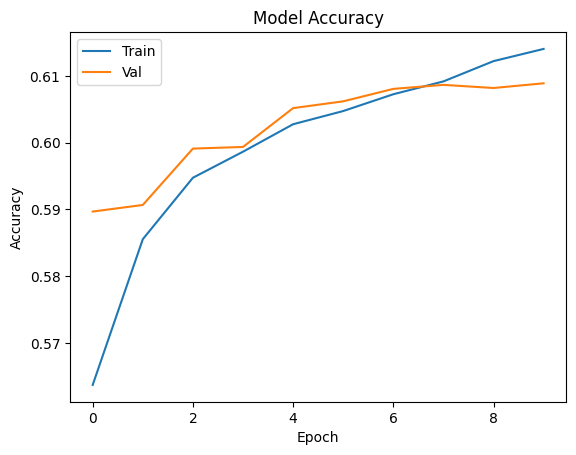

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'])
plt.show()

In [ ]:
loss, acc = clf.evaluate(X_test_flat, y_test_flat)
print("Test Accuracy:", acc)

2964/2964 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5969 - loss: 0.8772
Test Accuracy: 0.5968811511993408
